<font color="#de3023"><h1><b>REMINDER: MAKE A COPY OF THIS NOTEBOOK, DO NOT EDIT</b></h1></font>

#Designing a Color Classification App

In [40]:
#@title Run to Install Packages and Setup Environment { display-mode: "form" }

from google.colab import files
import zipfile
import io
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# potential solution
!pip install protobuf==3.20 &> /dev/null
!pip install tensorflow==2.8 &> /dev/null
!apt install --allow-change-held-packages libcudnn8=8.1.0.77-1+cuda11.2 &> /dev/null


!pip -q install streamlit &> /dev/null
!pip -q install pyngrok &> /dev/null
from pyngrok import ngrok

#not necessary for now
#!pip install tensorflowjs
#import tensorflowjs as tfjs

import json
from urllib.request import urlretrieve

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import Image
import os
import gdown

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

def capture_image(filename):
  try:
    take_photo(filename)
    print('Saved to {}'.format(filename))

    # Show the image which was just taken.
    display(Image(filename))
  except Exception as err:
    # Errors will be thrown if the user does not have a webcam or if they do not
    # grant the page permission to access it.
    print(str(err))

import numpy as np
import tensorflow as tf
import cv2
from google.colab.patches import cv2_imshow

# Ensure comptability with different TF versions
version_fn = getattr(tf.keras, "version", None)
if version_fn and version_fn().startswith("3."):
  import tf_keras as keras
else:
  keras = tf.keras

import warnings
warnings.filterwarnings('ignore')


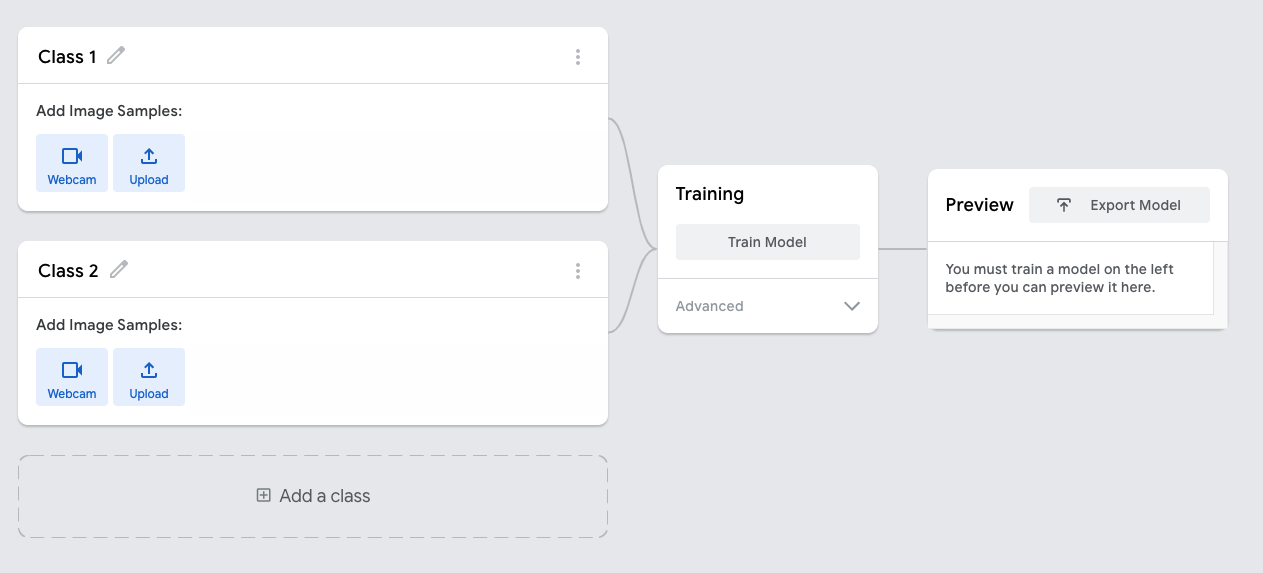





We've learned about all the amazing things that computer vision can do.
Now, let's design, train, and deploy our own **Color Detector App with [Google's Teachable Machine](https://teachablemachine.withgoogle.com/train/image)**!

We'll start by making an app to **recognize different colors**. You can make a different app after if you prefer!

#Let's start with some design questions!

In [41]:
#@title What's the title of your Image Classification App? (Press play!)

title = 'Fruits Classification' #@param {type:"string"}

print('Fantastic! Now let\'s start designing the details of ' + title )

Fantastic! Now let's start designing the details of Fruits Classification


In [42]:
#@title What is the primary purpose of this app?

purpose = 'Fruits detection' #@param {type:"string"}

print('Sounds interesting! Now let\'s start thinking about who might this app benefit.')

Sounds interesting! Now let's start thinking about who might this app benefit.


In [43]:
#@title Who might use this app?

user = 'James' #@param {type:"string"}

print('Great! It\'s super important to keep in mind the needs of your user!')

Great! It's super important to keep in mind the needs of your user!


# Training an Image Classifier App with Teachable Machine






**To begin, go to [Teachable Machine](https://teachablemachine.withgoogle.com/) by Google.**

There, you will:


1.   Name your image classes. (For example, different colors! Use at least 3.)
2.   Collect image data for each of your classes. (Make sure you have a variety of examples.)
3. Train your AI model.
4. Export your AI model.






When you export, make sure you select the Tensorflow tab and Keras before you download your model.
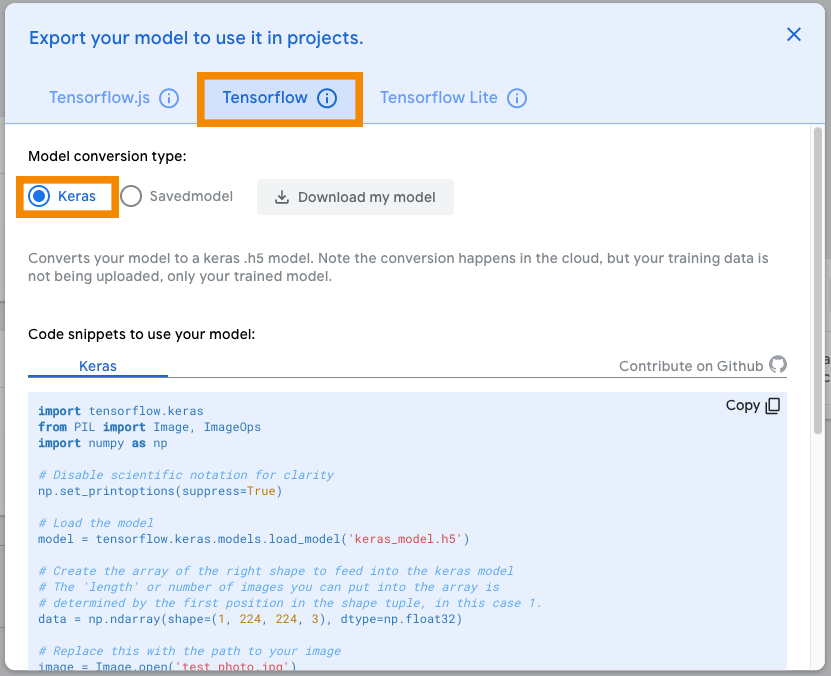

#Importing the Model to Google Colab

Great! Now, our AI model is ready to be tested out!

#Importing your model


First, upload the model that you have downloaded from Teachable Machine. It should be a ```.zip``` file format.

**Wait until it says 100% done before moving onto the next step!**

In [44]:
#@title Run this cell to upload and extract your model into Colab

# upload model zip file
uploaded = files.upload()

# extract model
try:
  file_name = list(uploaded.keys())[-1]
  print("Extracting model...")
  with zipfile.ZipFile(file_name, 'r') as zip_ref:
      zip_ref.extractall('')

  class_names = np.genfromtxt("labels.txt", dtype="str", delimiter='\n')
  for i in range(len(class_names)):
    class_names[i] = ' '.join(class_names[i].split(' ')[1::])

  predictions = [0.0] * len(class_names)

  model = keras.models.load_model('keras_model.h5', compile=False)
  print("Success! Model Extracted!")
except (IndexError, NameError):
  print("Oops! Cannot find file to unzip. Please try uploading a zip file for your model")

Saving converted_keras (1).zip to converted_keras (1) (1).zip
Extracting model...
Success! Model Extracted!


In [45]:
#@title Were you able to load your model?
#@markdown *(If not, set `model_loaded` to "No" and run the cell to extract Demo Model)*

model_loaded = "Yes" #@param ["Yes", "No"]
if model_loaded == "No":
  NEED_INSTRUCTOR = True
else:
  NEED_INSTRUCTOR = False

try:
  if NEED_INSTRUCTOR:
    !gdown 1DY8EBDAOuIYSOgft2se0xeCJhgjFe3YV
    np.set_printoptions(suppress=True)
    file_name = 'instructor_color_model.zip'
    print("Extracting model...")
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall('')

    class_names = np.genfromtxt("labels.txt", dtype="str", delimiter='\n')
    for i in range(len(class_names)):
      class_names[i] = ' '.join(class_names[i].split(' ')[1::])

    predictions = [0.0] * len(class_names)

    model = keras.models.load_model('keras_model.h5', compile=False)
    print("Success! Model Extracted!")
  else:
    print("It looks like your model works, so no need for the Instructor Model!")
except (IndexError, NameError):

    with zipfile.ZipFile('instructor_color_model.zip') as zip_ref:
      zip_ref.extractall()

    class_names = np.genfromtxt("labels.txt", dtype="str", delimiter='\n')
    for i in range(len(class_names)):
      class_names[i] = ' '.join(class_names[i].split(' ')[1::])

    predictions = [0.0] * len(class_names)

    model = keras.models.load_model('keras_model.h5', compile=False)
    print("Success! Instructor Model Extracted!")




It looks like your model works, so no need for the Instructor Model!


#Testing the Image Classification Model

###Capture Test Image

Let's test our our model with a sample image. To add a test image to the notebook, use the cell below to take a picture with your webcam or upload a picture from your computer! Make sure you use whichever method you used to train your model!

In [46]:
#@title Do you want to use the webcam or upload a picture?
#@markdown Choose your option and run the cell!

answer = "upload" #@param ["webcam", "upload"]

if answer == "webcam":
  image_name = 'test.jpg'
  capture_image(image_name)
else:
  uploaded = files.upload()
  image_name = list(uploaded.keys())[-1]


# Define functions to classify image
def get_image_classification(image_name):
  return classify_image(image_name)['classification']

def get_image_predictions(image_name):
  return classify_image(image_name)['predictions']

def get_best_prediction():
  return max(get_image_predictions())

def classify_image(image_name):
  image = cv2.imread(image_name)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  image = cv2.resize(image, (224, 224)).astype('float32')
  image = (image / 127.5) -1 #changed the normalization code from /255 to this
  image = np.expand_dims(image, axis=0)
  cv2_imshow(cv2.resize(cv2.imread(image_name), (224, 224))) #printing image
  predictions = model.predict(image)[0]
  pred_class = class_names[np.argmax(predictions)]

  return {'classification': pred_class, 'predictions': predictions}


Saving Mango (4).jpeg to Mango (4).jpeg


###Predicting the Image Class

Calling a function called ```get_image_classification()``` can help us see what classification our model gives us from our test image!

This may take a minute. As you wait, try to guess how your model will classify this image!

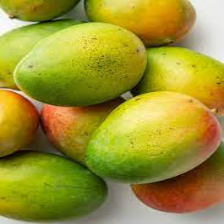

1/1 [==============================] - 1s 1s/step


In [47]:
classification = get_image_classification(image_name)

Please **print out the classification**:

In [48]:
#YOUR CODE HERE
print(classification)

Mango


**Discuss:** Did your model correctly classify the test image? Why or why not?

**What happens when your test image is something different from your training dataset?**

#Analyzing Image Classification Output (Optional)

Now let's take a closer look at how the model decided what to classify your image!

### Getting the Class Names

**Python lists** are used to store multiple items in a single variable. **In lists, the order of the items matter!**

The variable ```class_names``` is a Python list that holds all of our class names. Try printing it!

In [49]:
###YOUR CODE HERE
print(class_names)

['Apple' 'Banana' 'Grape' 'Mango' 'Strawberry']


**Discuss:** How many items are in this list? How does this compare to the number of classes you made when you trained your model in Teachable Machine?

We can use then ```len()``` function on any list to find out how many items are in the list without having to manually count.

Try running the ```len()``` function on ```class_names```!

In [50]:
###YOUR CODE HERE
print(len(class_names))

5


###Getting Class Predictions

Calling a function called `get_image_predictions()` and giving it the variable containing our test image (`image_name`) can help us see the corresponding probabilities for each class our model gives us from our test image! This will give us another list.



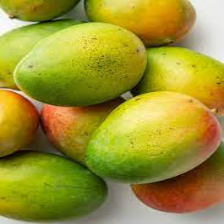

1/1 [==============================] - 0s 23ms/step


In [51]:
predictions = get_image_predictions(image_name)

Again, print the predictions:

In [52]:
#YOUR CODE HERE
print(predictions)

[2.1724666e-12 1.0117861e-18 3.7174221e-22 1.0000000e+00 1.3764011e-17]


**Discuss:** What do these numbers mean? How is the order of these numbers important?

Hint: Compare the order of these numbers with the order of the class names

Now, try using ```len()``` function on ```predictions``` to see the length of this list!

**Discuss:** Before you run the code - what do you expect the length of ```predictions``` to be?

In [53]:
###YOUR CODE HERE###
print(len(class_names))

5


###Plotting Classification Probabilities

Now, let's visualize how confident our model is by using a bar graph!
We can use ```sns.barplot()``` to make a bar graph.

Fill in the code to make a bar chart!

* We want the ```class_names``` to be our ```x```, and ```predictions``` to be
our ```y```.

* We want the "Class Names" to be our x-axis label, and "Predictions" to be
our y-axis label.



[2.1724666e-12 1.0117861e-18 3.7174221e-22 1.0000000e+00 1.3764011e-17]
['Apple' 'Banana' 'Grape' 'Mango' 'Strawberry']


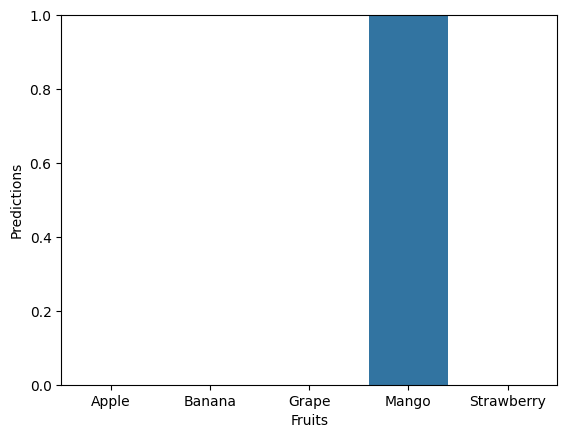

In [54]:
print(predictions)
print(class_names)

plt.ylim(0.00, 1.00)

###YOUR CODE HERE

chart = sns.barplot(x = class_names, y = predictions) #REPLACE THE X AND Y WITH THE CORRECT DATA
chart.set(xlabel="Fruits", ylabel = "Predictions")

####


plt.show()


**Discuss:** How confident was your model of its final image classification? How might this influence the output of your app?

#Deploying Your Model On Streamlit

We're going to create a web app using [Streamlit](https://www.streamlit.io/), which is a *library*: like an extension to Python with special powers.


In [55]:
#@title First, run this to set up Streamlit!
print("Setting up Streamlit...")
#print("Don't worry if you see ERROR here!")

!pip -q install streamlit
!pip -q install pyngrok
from pyngrok import ngrok

def launch_website():
  try:
    if ngrok.get_tunnels():
      ngrok.kill()
    tunnel = ngrok.connect()

    print("Click this link to try your web app:")
    print(tunnel.public_url)

    !streamlit run --server.port 80 app.py >/dev/null # Connect to the URL through Port 80 (>/dev/null hides outputs)

  except KeyboardInterrupt:
    ngrok.kill()

print("Done!")

Setting up Streamlit...
Done!


<font color=SlateGrey><h2><b>
Your instructor will guide you through setting up ngrok accounts and getting authtokens using [these](https://drive.google.com/file/d/12zwuOuKh91VSHIHS-6S4ADF4HLC2wKJq/view?usp=sharing) instructions!
</b></h2></font>

<font color=DarkGray><h3><b>
Paste your authtoken below next to `!ngrok authtoken`!
</b></h3></font>

In [56]:
!ngrok authtoken 30H0oWdFXzNrGl9V87AscW1UxwG_5nXzWEJ3E1vNoyV7sDCE5

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


### Creating an Example App

Let's start by creating a super-simple website. Try filling in a title for your web app here:

In [57]:
%%writefile app.py
#We'll need this line for our web app code!

import streamlit as st
#This line means that when you see "st", you're using Streamlit!

st.title("Fruits Classification")

Overwriting app.py


Once you've run the code above, we can see our web app in action! Run the code below and click the "ngrok.io" link. It'll be public as long as the cell is running - you can even check it out on your phone!

(If you get an error, stop the cell, run it again, and wait a couple of seconds before clicking.)

In [ ]:
#Run this function whenever you edit your web app!
launch_website()

Click this link to try your web app:
https://7f627fbd0b4d.ngrok-free.app
2025-07-23 13:12:39.475 Session with id 7e00c835-fb3e-4fad-aada-67e26ab86a28 is already connected! Connecting to a new session.


Cool!

The next thing we can do is add text. When we're working with Streamlit, instead of `print` we'll use `st.write("YOUR TEXT HERE").`

**Edit and re-run your web app code above to add text after your title!**

### Creating an AI Vision App

Now, let's get our AI vision app set up. First, we'll create the heading of our app by adding a title, name, and description!
We recommend using functions like ```st.title()```, ```st.header()```, and ```st.subheader()```, and ```st.write()```.

1. First, let's set up the name of your AI Vision Bot.

2. Next, write your name under the title. You can also use a fake name or alias if you prefer.

3. Now, write a description outlining about who this Vision Bot would be useful for and what it can do!

  An example of a good description can be: This vision AI can help ```insert user here``` do ```insert task here```.



In [ ]:
%%writefile header.py
import streamlit as st
import streamlit.components.v1 as components

def create_header():
  ### FILL IN YOUR CODE FOR TITLE, NAME, AND DESCRIPTION HERE
  st.title('FRUITS IMAGE CLASSIFICATION APP')
  st.header('Convolutional Neural Network (CNN)')
  st.subheader('Fruits Classification')
  st.write('This project aims to build a Convolutional Neural Network model that can classify images of different fruits into their correct categories')
  pass


###Customizing Our App Responses

Now, let's add some responses for our app! Once our app classifies an image, it can help send a message depending on the classification. Based off the ```class_names``` from above, come up with responses for each case. **Make sure you spell and capitalize your class names exactly like they appear above!**

In [43]:
%%writefile response.py
import pandas as pd
import streamlit as st
import streamlit.components.v1 as components

def get_app_response(classification, probability):
  if classification == "FACIAL DETECTION":
    st.write("showcase or to dectect")
  #ADD MORE IF / ELIF STATEMENTS HERE
  else:
    st.write("FILL ME IN")

Overwriting response.py


**Optional:** You can also try to make things more interesting by having more cases based on the ```probability``` of your model being right. ```probability``` will give a number anywhere from ```0.0``` to ```1.00```. Try playing around with nested ```if``` statements!

Great! Now we can properly set up the AI computer vision model to add into your app!

In [44]:
#@title Run this to set up your model in your app!
%%writefile classifier.py
import streamlit as st
import streamlit.components.v1 as components

import numpy as np
import tensorflow as tf
import cv2

class_names = np.genfromtxt("labels.txt", dtype="str", delimiter='\n')
for i in range(len(class_names)):
  class_names[i] = ' '.join(class_names[i].split(' ')[1::])
np.set_printoptions(suppress=True)

# Ensure comptability with different TF versions
version_fn = getattr(tf.keras, "version", None)
if version_fn and version_fn().startswith("3."):
  import tf_keras as keras
else:
  keras = tf.keras

model = keras.models.load_model('keras_model.h5', compile = False)

def get_image_classification(uploaded_file):
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    image = cv2.imdecode(file_bytes, 1)


    st.image(image, channels="BGR")

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    rgb = cv2.resize(rgb,(224,224)).astype('float32')
    rgb = np.reshape(rgb,(1,224,224,3))
    rgb = rgb / 255



    predictions = model.predict(rgb)[0]
    classification = class_names[np.argmax(predictions)]
    return classification, predictions

Overwriting classifier.py


Now we can put everything together: your headings, your model, and an image uploader where we can test out your AI model!

In [45]:
#@title Run this to put everything together!
%%writefile app.py
import streamlit as st
import streamlit.components.v1 as components

import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
from header import *
from classifier import *
from response import *

create_header()
uploaded_image = st.file_uploader("Upload Image")

if uploaded_image is not None:
    classification, predictions = get_image_classification(uploaded_image)

    get_app_response(classification, predictions)


Overwriting app.py


Finally, let's launch our app!
Run this block, then click the URL to access your webpage: it'll be accessible until you stop the code block. You can also check it out on your phone.

In [1]:
launch_website()

NameError: name 'launch_website' is not defined

#Optional: Design your Own Image Classification App
Congratulations! You have now launched your first computer vision app!

Now, let's design, train, and deploy your own app for another scenario!
**Choosing objects around you or yourself**, be creative in designing an Image Classifier app! Think of this like an AI Chatbot, but with vision instead.

Some examples for inspiration can be:

* An emotion detector that can make you feel better when you're feeling sad
* A banana ripeness detector that can help you decide the best time to eat it, or if it's best to make banana bread out of it
* A sign language translator
* A water level detector that can remind you to refill your water bottle
* A trash / recyclable material sorter
* A recipe suggestor based off of a food item

**Questions to discuss:**
* What are some ethical concerns of your app?
* Who might this app affect if it were to be released to the public?
* How can you make the app perform better?
* Are are some additional classes you can add?
* What are additional images you can use your app?
* What are some limitations of your app?



# Want to go further?
*   Evaluate what images are misclassified and try retraining your model on Teachable Machine!
*   Consider making your app responses be based on how confident your model is for each classification
*   Add some personality to the responses on your app!
*   Add additional custom Streamlit components into your app! Check out the [Streamlit Cheat Sheet](https://github.com/daniellewisDL/streamlit-cheat-sheet/blob/master/streamlit-cheat-sheet.png) or the Streamlit Toolbox below.

In [ ]:
#Your Streamlit Toolbox!

"""
#Write text
st.write("text")

#Title
st.title('title')

#Header
st.header('header')

#Slider
value = st.slider('variable')

#Table
st.table(dataframe) #use a Pandas DataFrame

#Bar Chart (Example)
chart_data = pd.DataFrame({"predictions": predictions}, index = class_names)
st.bar_chart(chart_data)

#Matplotlib Figure
st.pyplot(fig) #use a Matplotlib figure

#Image
st.image(image, caption='Image Caption')

#Button
pressed = st.button('Button Name')

#Checkbox
checked = st.checkbox('Checkbox Name')

#File Input
uploaded_file = st.file_uploader("Upload File")

if uploaded_file is not None:
    pass #Do something here!

"""